In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Damiano Degliotti, Daniele Melaccio

In [2]:
from sklearn.preprocessing import StandardScaler

import cup_common as cc
import nn_common as nnc
import cross_common as cr
import torch
import torch.nn as nn
import importlib
from functools import partial
import pandas as pd
import copy
from cross_common import MEE,MSE,RMSE,MAE,R2

importlib.reload(nnc)
importlib.reload(cc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h1>NN - Manual</h1>
<h2>Exploring the CUP dataset with a neural network regressor.</h2>
<p>This notebook serves the purpose of exploring the hypotesis space by manually varying the hyperparameters and for inspecting the whole pipeline.</p>
<hr/>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [3]:
importlib.reload(cr)
df_train, df_test = cc.load_set()

# The train set used for model selection
# not scaled because the kfold and train phases
# will take care of the scaling
X_tr, y_tr = cc.prepare_dataset(df_train)
X_ts, y_ts = cc.prepare_dataset(df_test)

# The train and set scaled
scaler = StandardScaler()
X_tr_scaled, y_tr_scaled = cc.prepare_dataset(df_train, scaler=scaler, fit_scaler=True)   # fit+transform
X_ts_scaled, _ = cc.prepare_dataset(df_test, scaler=scaler, fit_scaler=False)


# Important!!!! The following dataset is prepared for investigation purpose and dry run of the NN pipeline,
# in order to check for correctness of function calls and graphics plot
# it is absolutely not meant to be used for model selection
dry_run_scaler = StandardScaler()
X_tr_dry_run, y_tr_dry_run, X_ts_dry_run, y_ts_dry_run = cc.prepare_dataset_for_hold_out(df_train, ratio=0.2, scaler=dry_run_scaler)

features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,500,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [4]:
# Set to True when model is selcted and assessed
dump_prediction = False

# Optuna parameters
optuna_epochs = 1000
optuna_batch_size = 16
optuna_learning_rate = 0.008206725313798213 # <-- optuna
#optuna_learning_rate = 0.01
optuna_weight_decay = 1.6183611167820987e-05 # <-- optuna
#optuna_weight_decay = 1e-4
#optuna_weight_decay = 5e-5
#optuna_hidden_layers = [256, 128, 64] # <-- optuna
#optuna_hidden_layers = [64, 32]
optuna_hidden_layers = [128, 64]
optuna_activation = "gelu"


# The seed to be used by data splitter
default_state = cr.RANDOM_STATE
default_seed = cr.SEED


# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 4


# ----- Defining model architecture --------
hidden_layers = optuna_hidden_layers
net = nnc.build_nn_net(input_dimension, output_dimension, hidden_layers, optuna_activation)

# The output and loss function, must be changed according to the type of task
#loss_function = nn.MSELoss()
loss_function = nnc.MEELoss()
output_adapter = nnc.regression_adapter()

# Model implementation
model_template = nnc.build_nn_model(net, output_adapter)
# ------------------------------------------


# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.AdamW,
    lr=optuna_learning_rate,
    weight_decay=optuna_weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by learning rate will decrease
learning_rate_decay_factor = 0.5 #0.7    #0.6 #0.5
# The epoch to wait before applying the rate decay factor
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2 #1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", threshold_mode = "abs", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-2 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = nnc.EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------


# ---- The additional metrics to compute ---
metrics_dict = {
    # The loss function is implicitly added during training
    MSE: (cr.mse,min),
    MAE: (cr.mae,min),
    RMSE: (cr.rmse,min),
    #R2: (cr.r2,max),
}
the_metrics = [cr.LOSS] + list(metrics_dict.keys())
# ------------------------------------------


<h3>NN Run</h3>
<p>The NN run is separated in two distinct scenarios independent from each other:
<ol>
<li>Hold-out: meant to be used for inspecting the correctness of the whole pipeline (i.e. no error, effectiveness of learning rate decay, plotting etc...).</li>
<li>KFold: meant to be used for model selection and asessment eventually leading to testing evaluation.</li>
</ol>
</p>
<hr/>

<h4>KFold</h4>
<p>Model selection is performed using K-Fold cross-validation on the training data, while an initial hold-out split was used only for preliminary analysis and debugging.</p>

<h5>Run</h5>

In [5]:
importlib.reload(nnc)
importlib.reload(cc)

# The KFold strategy to be used through all models
outer_cv = cr.common_fold_strategy()


inner_train_params = {
    "epochs": optuna_epochs,
    "batch_size": optuna_batch_size,
    "scheduler_template": scheduler_template,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy,
    "additional_metrics": metrics_dict,
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, outer_cv, inner_train_params, scaler
)


  
Perform fold: 0, train size: 400, val size: 100
Early stopping at epoch 100 (best VL loss: 21.3162)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 400
Validation      | samples: 100
Batch type      | mini-batch (16)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.008206725313798213, 'weight_decay': 1.6183611167820987e-05, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'threshold_mode': 'abs', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | best epoch: 51 metric: loss,  patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 400, val size: 100
Early stopping at epoch 114 (best VL loss: 19.1280)
Train summary
---------------------

In [6]:
import numpy as np

# From: ML-25-Valid3-v.0.1.pdf
# "So, much BETTER, if you consider the mean of TR error at the best point for VL and use it to
# gain the same level of fitting in the retraining (avoiding undertraning effects)."
target_training_loss = float(np.mean([
    fold.fold_tr_loss
    for fold in fold_histories
]))

print(target_training_loss)

15.49430746459961


<h5>Training</h5>
<p>Training the model.</p>

In [7]:
median_best_epoch = nnc.find_best_median_epochs(fold_histories)
print(median_best_epoch)

63


In [8]:
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.79302825927734
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-36.10307312 -34.5480423  -35.62013626 -35.9157486  -36.77814102]


<h5>Metrics</h5>
<p>Main metrics used for model assessment.
</p>

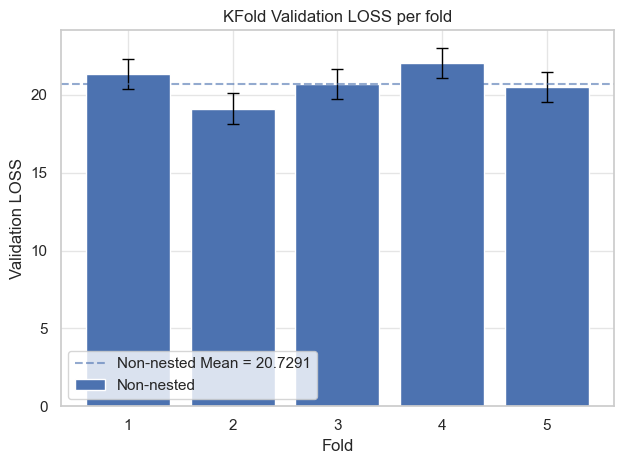

,TR,VL,|TR-VL|
Fold,,,
1,16.125794,21.316224,5.190430
2,15.381443,19.128025,3.746582
3,15.090757,20.685875,5.595118
4,14.501508,22.029833,7.528325
5,16.372035,20.485708,4.113673
MEAN,15.494307,20.729133,5.234825
STD,0.682704,0.965523,1.331448


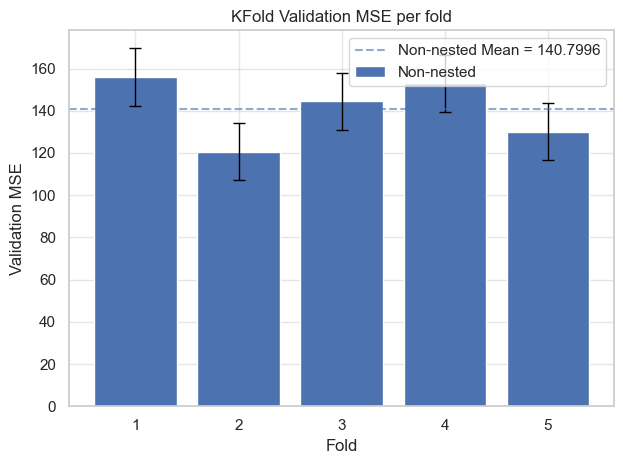

,TR,VL,|TR-VL|
Fold,,,
1,95.453289,156.016440,60.563152
2,88.306640,120.574919,32.268279
3,86.145401,144.530483,58.385082
4,77.886221,152.903738,75.017517
5,96.736481,129.972590,33.236110
MEAN,88.905606,140.799634,51.894028
STD,6.835190,13.551706,16.644946


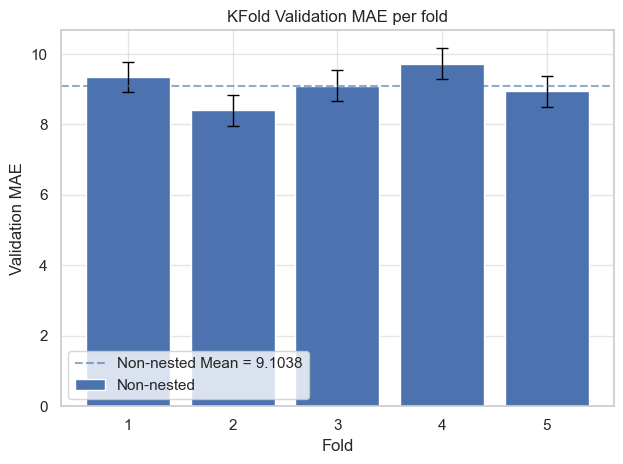

,TR,VL,|TR-VL|
Fold,,,
1,7.073350,9.346517,2.273167
2,6.766581,8.398509,1.631929
3,6.619729,9.104286,2.484556
4,6.329378,9.722797,3.393419
5,6.677476,8.946804,2.269328
MEAN,6.693303,9.103782,2.410480
STD,0.239963,0.439124,0.568608


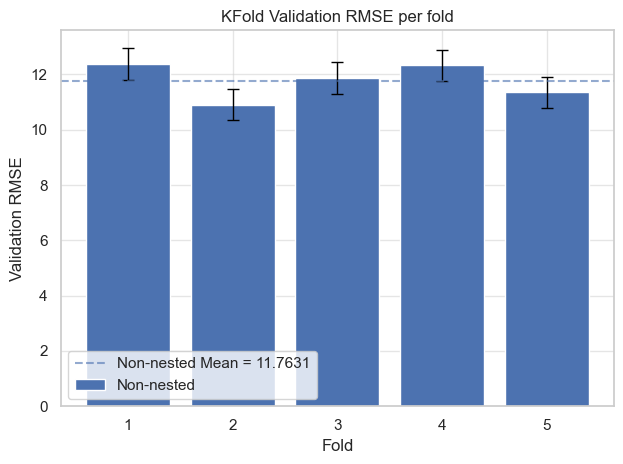

,TR,VL,|TR-VL|
Fold,,,
1,9.649423,12.375321,2.725897
2,9.218277,10.904352,1.686075
3,9.222140,11.862389,2.640248
4,8.675059,12.324452,3.649393
5,9.711049,11.348909,1.637860
MEAN,9.295190,11.763084,2.467895
STD,0.372622,0.567237,0.747316


In [9]:
for metric in the_metrics:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_summary(fold_histories, use=metric))

<h4>Hold-out</h4>
<p>A fixed hold-out split is used to visualize the training and validation learning curves, analyze the model’s convergence and generalization behavior, and identify the best epoch through early stopping.</p>

In [10]:
importlib.reload(nnc)
importlib.reload(cr)
model_holdout = copy.deepcopy(model_template)
inner_train_params_holdout = copy.deepcopy(inner_train_params)
hold_out_scaler = StandardScaler()

hold_out_result = nnc.train(
    model_holdout, nnc.HoldOutStrategy(nnc.FeatureTargetSet(X_tr, y_tr), seed=default_seed, scaler=hold_out_scaler),
    **inner_train_params_holdout
)

Early stopping at epoch 108 (best VL loss: 21.0846)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 400
Validation      | samples: 100
Batch type      | mini-batch (16)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.008206725313798213, 'weight_decay': 1.6183611167820987e-05, 'betas': (0.95, 0.999)}
LR Decay        | params: {'mode': 'min', 'threshold_mode': 'abs', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | best epoch: 59 metric: loss,  patience: 50 , minimum delta: 0.01
----------------------------------------------------------------------------------------------------


In [11]:
epochs_tr_mee = hold_out_result.epochs_tr_loss
epochs_vl_mee = hold_out_result.epochs_vl_loss
epochs_grad = hold_out_result.epochs_grad_norm
best_hold_out_epoch = hold_out_result.best_epoch

<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

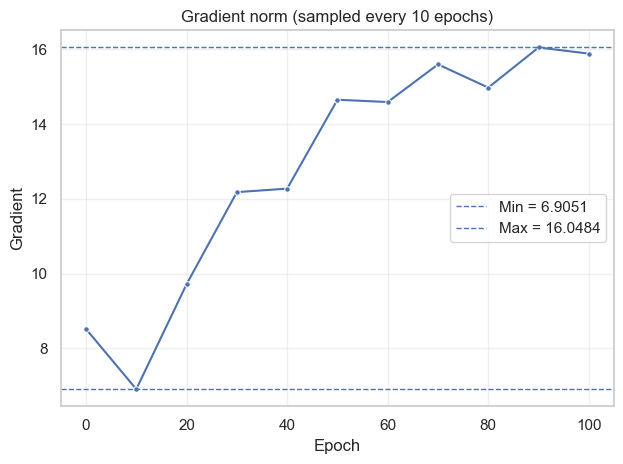

In [12]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_grad, step=10)

<h5>Epoch Loss</h5>

<Figure size 640x480 with 0 Axes>

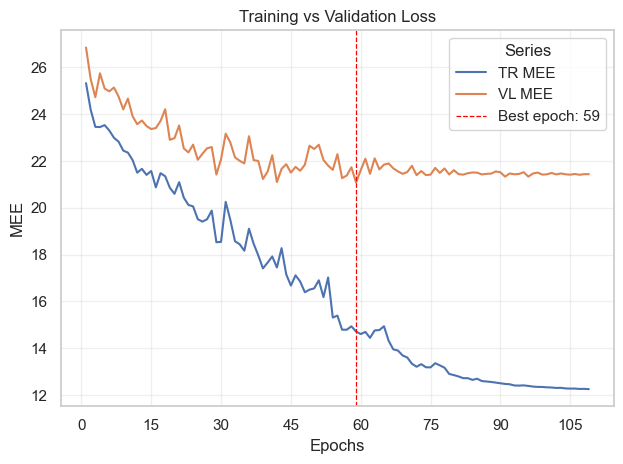

In [13]:
importlib.reload(nnc)
nnc.plot_epoch_mee(epochs_tr_mee, epochs_vl_mee, best_hold_out_epoch)

In [14]:
best_vl_mee = min(hold_out_result.epochs_vl_loss)
best_epoch = hold_out_result.epochs_vl_loss.index(best_vl_mee)
print(f"min MEE: {best_vl_mee} - best epoch: {best_epoch+1}")

min MEE: 21.08464485168457 - best epoch: 59


<h4>Bootstrap-OOB Stability Analysis</h4>
<p>Bootstrap is applied to approximate the sampling distribution of the estimator when only a finite dataset is available. By generating multiple resampled datasets, we can estimate variance, assess model stability, and better understand generalization behavior.</p>

In [15]:

epochs_metrics_bootstrap_dict = {
    MEE: (cr.mee, min)
}

importlib.reload(cr)
importlib.reload(nnc)
bootstrap_samples_nr = 100
bootstrap_rstate = cr.RANDOM_STATE
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples_nr, random_state=bootstrap_rstate)
runner = nnc.TorchRegressorRunner(model_template)
bootstrap_params = {}
bootstrap_params['train_params'] = copy.deepcopy(inner_train_params)
bootstrap_params['train_params']["silence_output"] = True
#bootstrap_params['train_params']["epochs"] = median_best_epoch
bootstrap_params["train_params"]["train_control"] = target_training_loss
bootstrap_params['scaler'] = StandardScaler()
bootstrap_params['split_strategy'] = nnc.FullTrainingStrategy
bootstrap_params['train_params'].pop("scheduler_template", None)
bootstrap_params['train_params'].pop("early_stopping_strategy", None)
bootstrap_scores = cr.bootstrap_out_of_bag_scores(runner, X_tr, y_tr, samples, epochs_metrics_bootstrap_dict, bootstrap_params)

In [16]:
cr.aggregate_scores(bootstrap_scores)

,Metric,Mean,Std,%
0,MEE,22.23,0.86,3.87


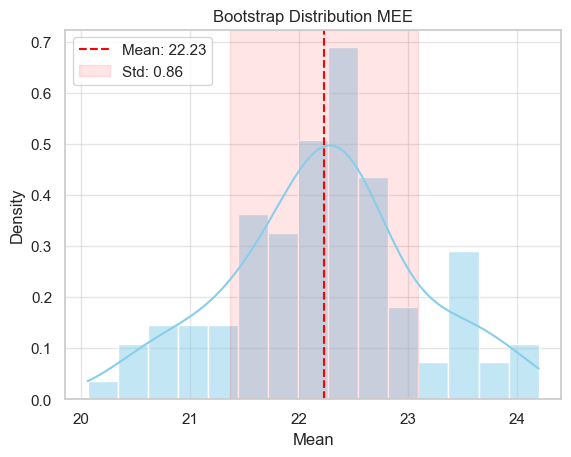

In [17]:
cr.plot_bootstrap_distribution([metric[MEE] for metric in bootstrap_scores], title=f"Bootstrap Distribution {MEE.upper()}")

In [18]:
save_report = False
if save_report:
    metrics={}
    for metric, value in zip(["mee", "mse", "mae"],[
        ([f.fold_vl_mee for f in fold_histories],[f.fold_tr_mee for f in fold_histories]),
        ([f.fold_vl_mse for f in fold_histories],[f.fold_tr_mse for f in fold_histories]),
        ([f.fold_vl_mae for f in fold_histories],[f.fold_tr_mae for f in fold_histories])
        ]):

        metrics[metric] = (cr.mean_std_from_kfold(value[0]), cr.mean_std_from_kfold(value[1]))
        nnc.save_run_report(model_baseline, net,inner_train_params,metrics)

<h4>Final model</h4>
<p>Model is eventually trained with best parameters verified from KFold, in order to predict on official test set.</p>

In [19]:
importlib.reload(nnc)

model_final = copy.deepcopy(model_template)
inner_train_params_final = copy.deepcopy(inner_train_params)
# For full retraining we rely on the target train loss at the best epoch VL
# instead of using early stopping and scheduler template
inner_train_params_final.pop("scheduler_template")
inner_train_params_final.pop("early_stopping_strategy")
inner_train_params_final["train_control"] = target_training_loss

train_final_result = nnc.train(
    model_final, nnc.FullTrainingStrategy(nnc.FeatureTargetSet(X_tr_scaled, y_tr_scaled)),
    **inner_train_params_final
)

Train control at epoch 57 (15.44261612701416 <= 15.49430746459961)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 500
Validation      | samples: None
Train control   | limit: 15.49430746459961
Batch type      | mini-batch (16)
Loss function   | MEELoss(reduction='mean') - custom function
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.008206725313798213, 'weight_decay': 1.6183611167820987e-05, 'betas': (0.95, 0.999)}
LR Decay        | disabled
Early Stopping  | disabled
----------------------------------------------------------------------------------------------------


In [20]:
epochs_final_tr_mee = train_final_result.epochs_tr_loss
epochs_final_tr_mse = train_final_result.epochs_tr_mse
epochs_final_tr_mae = train_final_result.epochs_tr_mae
epochs_final_grad = train_final_result.epochs_grad_norm


<h3>Prediction</h3>
<p>Final model prediction if needed.</p>

In [21]:
importlib.reload(nnc)
all_pred = model_final.predict(X_ts_scaled)
y_pred = all_pred[0].detach().cpu().numpy()
print(y_pred)

[[ -1.8858461   -2.1373756    3.6476562   -9.840418  ]
 [ -7.5552998   -1.6250606  -31.06787     25.359415  ]
 [ -4.1720915   -1.6618525  -12.177694     2.7977016 ]
 ...
 [ -5.6095695   15.123729    10.963244   -12.530245  ]
 [  6.9307156   26.452072   -12.224655    36.108116  ]
 [ -0.84628606   1.3653399    7.252263    -3.880064  ]]
